# Análise de Dados — E-commerce Olist

## Sobre o projeto

Este notebook tem como objetivo explorar os dados de vendas do **Olist**, um marketplace 
brasileiro de e-commerce, cruzando informações de pedidos, clientes e itens comprados 
para responder perguntas de negócio relacionadas a **logística, vendas e satisfação do cliente**.

## Perguntas que este projeto busca responder

- Qual a porcentagem de pedidos que atrasam?
- Qual o tempo médio de entrega (da compra até o cliente receber)?
- Quais estados têm a maior taxa de atraso?
- Existe tendência de atraso ao longo dos meses?
- Qual o ticket médio por pedido e como ele varia por estado?
- Quais categorias de produto vendem mais?

## Bases de dados utilizadas

| Arquivo | Conteúdo |
|---|---|
| `olist_orders_dataset.csv` | Pedidos: status e datas (compra, aprovação, entrega, estimativa) |
| `olist_customers_dataset.csv` | Clientes: localização (cidade, estado, CEP) |
| `olist_order_items_dataset.csv` | Itens de cada pedido: produto, vendedor, preço e frete |

## Estrutura do notebook

1. **Importação das bibliotecas**
2. **Carregamento dos dados**
3. **Limpeza dos dados** (valores nulos e duplicatas)
4. **Criação de colunas derivadas** (tempo de entrega, atraso)
5. **Merge das tabelas** (orders + customers + order_items)
6. **Análise exploratória** (estatísticas descritivas e visualizações)
7. **Conclusões**

---

## 1. Importando as bibliotecas que iremos usar

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

***
## Carregando os arquivos

In [2]:
df_entregas = pd.read_csv("../data/olist_orders_dataset.csv")
df_customers = pd.read_csv("../data/olist_customers_dataset.csv")
df_items = pd.read_csv("../data/olist_order_items_dataset.csv")

***
# Retirando todo o qualquer valor nulo das tabelas.

In [3]:
df_entregas = df_entregas.dropna()
df_customers = df_customers.dropna()
df_items = df_items.dropna()

***
## Verificalçao de duplicatas

In [4]:
#verificando se há duplicatas na tabela em geral
print(df_customers.duplicated().sum())
print(df_entregas.duplicated().sum())

0
0


In [5]:
#Verificando se há duplicatas no ID
print(df_customers['customer_id'].duplicated().sum())
print(df_entregas['customer_id'].duplicated().sum())

0
0


In [6]:
print(df_items.duplicated().sum())
print(df_items.duplicated().sum())

0
0


***
## Utilizamos o merge para unirmos a tebla entregas e cliente mantendo o lado direito completo

In [7]:
df_customer_entregas = pd.merge(df_customers,df_entregas, on='customer_id', how='left')

In [8]:
df_customer_entregas.to_csv("lista de clientes e entregas.csv", index=False)
df_customer_entregas

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25 00:00:00
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20 00:00:00
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02 00:00:00
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05 00:00:00


***

## Transformando os tipos datas de object para datetime

In [9]:
df_customer_entregas["order_purchase_timestamp"] = pd.to_datetime(df_customer_entregas["order_purchase_timestamp"],format="%Y-%m-%d %H:%M:%S")
df_customer_entregas["order_approved_at"] = pd.to_datetime(df_customer_entregas["order_approved_at"],format="%Y-%m-%d %H:%M:%S")
df_customer_entregas["order_delivered_carrier_date"] = pd.to_datetime(df_customer_entregas["order_delivered_carrier_date"],format="%Y-%m-%d %H:%M:%S")
df_customer_entregas["order_delivered_customer_date"] = pd.to_datetime(df_customer_entregas["order_delivered_customer_date"],format="%Y-%m-%d %H:%M:%S")
df_customer_entregas["order_estimated_delivery_date"] = pd.to_datetime(df_customer_entregas["order_estimated_delivery_date"],format="%Y-%m-%d %H:%M:%S")

***
## Criando a coluna tempo de entrega em dias

In [10]:
df_customer_entregas['tempo_entrega_dias'] = (df_customer_entregas['order_delivered_customer_date'] - df_customer_entregas['order_purchase_timestamp']).dt.days

***
## Criando as colunas atrasou e dias de atraso
### Nesta colunas conseguiresmos extrair se houve atraso em algum pedido ou não

In [11]:
df_customer_entregas['atrasou'] = df_customer_entregas['order_delivered_customer_date'] > df_customer_entregas['order_estimated_delivery_date']
df_customer_entregas['dias_atraso'] = (df_customer_entregas['order_delivered_customer_date'] - df_customer_entregas['order_estimated_delivery_date']).dt.days

***
## Efetuarmos o ultimo merge com o dataframe colocando o items que contem os valores dos pedidos dos clientes

In [12]:
df_final = df_customer_entregas.merge(df_items, on='order_id', how='left')

In [13]:
df_final.to_csv("../data/dataframe final.csv", index=False)

In [34]:
df_pedidos_unicos = df_final.drop_duplicates(subset='order_id')
print(df_pedidos_unicos['atrasou'].mean() * 100)


7.870998883760219


In [62]:
df_pedidos_unicos.to_csv("../data/Pedidos unicos.csv")

### Aproximadamente 8% dos pedidos foram entregues com atraso, indicando um bom desempenho logístico geral.
***

In [35]:
df_pedidos_unicos.groupby('customer_state')['atrasou'].mean().sort_values(ascending=False) * 100

# Quantos pedidos por status
df_pedidos_unicos['order_status'].value_counts()

# Tempo médio de entrega
df_pedidos_unicos['tempo_entrega_dias'].mean()

np.float64(12.094085575687217)

In [36]:
# Ticket médio por estado (pedidos únicos, não itens)
round(df_final.drop_duplicates(subset='order_id').groupby('customer_state')['price'].mean() * 100,2)

# Atraso por estado (pedidos únicos)
round(df_final.drop_duplicates(subset='order_id').groupby('customer_state')['atrasou'].mean() * 100, 2)

customer_state
AC     3.70
AL    23.00
AM     4.05
AP     4.41
BA    13.52
CE    14.67
DF     6.87
ES    12.00
GO     7.92
MA    18.88
MG     5.48
MS    11.33
MT     6.62
PA    12.00
PB    10.63
PE    10.41
PI    15.35
PR     4.88
RJ    12.95
RN    10.52
RO     2.77
RR    10.87
RS     6.99
SC     9.51
SE    14.57
SP     5.72
TO    12.50
Name: atrasou, dtype: float64

In [37]:
df_pedidos_unicos['customer_state'].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

***
## Análise exploratória

In [38]:
df_final[['price', 'freight_value', 'dias_atraso', 'tempo_entrega_dias']].describe()

,price,freight_value,dias_atraso,tempo_entrega_dias
count,112650.000000,112650.000000,110196.000000,110196.000000
mean,120.653739,19.990320,-12.030201,12.007723
std,183.633928,15.806405,10.160157,9.451455
min,0.850000,0.000000,-147.000000,0.000000
25%,39.900000,13.080000,-17.000000,6.000000
50%,74.990000,16.260000,-13.000000,10.000000
75%,134.900000,21.150000,-7.000000,15.000000
max,6735.000000,409.680000,188.000000,209.000000


In [39]:
df_pedidos_unicos['tempo_entrega_dias'].median()

10.0

In [40]:
df_pedidos_unicos['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [41]:
df_pedidos_unicos.groupby('order_id')['price'].sum().mean()

np.float64(124.9826159230096)

In [44]:
df_pedidos_unicos["customer_city"].value_counts().head(10)

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64

In [47]:
df_pedidos_unicos["ano_mes"] = df_pedidos_unicos["order_purchase_timestamp"].dt.month
df_pedidos_unicos.groupby("ano_mes")["atrasou"].mean() * 100

C:\Users\gusta\AppData\Local\Temp\ipykernel_15576\1938725267.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pedidos_unicos["ano_mes"] = df_pedidos_unicos["order_purchase_timestamp"].dt.month


ano_mes
1      6.035444
2     12.952515
3     16.557162
4      5.801135
5      6.469309
6      2.167446
7      3.963947
8      7.368809
9      5.040650
10     4.839685
11    13.825557
12     8.142404
Name: atrasou, dtype: float64

In [48]:
df_pedidos_unicos[df_pedidos_unicos['dias_atraso'] > 100][['order_id', 'customer_state', 'order_status', 'dias_atraso']]

,order_id,customer_state,order_status,dias_atraso
4120,440d0d17af552815d15a9e41abe49359,PA,delivered,165.0
4336,815b68de0bc7fa6c117e4bcf855734ef,BA,delivered,111.0
5232,ed8e9faf1b75f43ee027103957135663,SP,delivered,153.0
7050,a452fba32eab28a4a62af18eed010c0b,BA,delivered,138.0
11661,525e11b26fdb7f41471d289897d0f6da,BA,delivered,134.0
13472,c5f43352377291361dad9a7366ae1c89,BA,delivered,109.0
14444,17cc6728043d53cc948551dfbf0a338b,CE,delivered,110.0
19366,0b7b12a402b064d880d3cb31051f6d29,BA,delivered,104.0
24915,285ab9426d6982034523a855f55a885e,SE,delivered,166.0
24917,e7fc47a9bd5fd8c1d1b566d1553be0f4,MG,delivered,104.0


In [49]:
# Ver se BA tem uma taxa de atraso extremo maior que a média
df_pedidos_unicos[df_pedidos_unicos['customer_state'] == 'BA']['dias_atraso'].describe()

count    3256.000000
mean      -10.794533
std        12.828845
min       -65.000000
25%       -18.000000
50%       -12.000000
75%        -6.000000
max       138.000000
Name: dias_atraso, dtype: float64

***
### Matriz de correlação

In [60]:
colunas = [
    "price",
    "freight_value",
    "tempo_entrega_dias",
    "dias_atraso"
]

correlacao = df_final[colunas].corr()
correlacao

,price,freight_value,tempo_entrega_dias,dias_atraso
price,1.000000,0.414204,0.062290,-0.003596
freight_value,0.414204,1.000000,0.214631,-0.040242
tempo_entrega_dias,0.062290,0.214631,1.000000,0.597315
dias_atraso,-0.003596,-0.040242,0.597315,1.000000


***
## Visualização dos dados

### Gráfico 1 — Proporção de Pedidos Atrasados vs No Prazo

Este gráfico de pizza mostra a distribuição geral dos pedidos entre **atrasados** 
e **entregues no prazo**, considerando a data de entrega real em comparação 
com a data estimada.

**Resultado:** 92,1% dos pedidos foram entregues dentro do prazo, enquanto 7,9% 
atrasaram. Isso indica uma taxa de atraso relativamente baixa no geral, mas que 
ainda representa quase 1 a cada 12 pedidos.

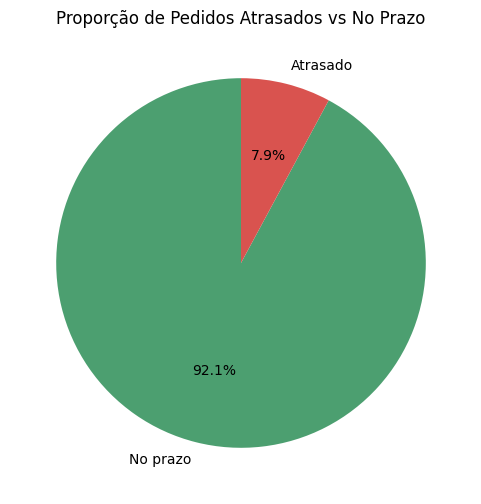

In [50]:
plt.figure(figsize=(6,6))
contagem = df_pedidos_unicos['atrasou'].value_counts()
labels = ['No prazo', 'Atrasado']
colors = ['#4C9F70', '#D9534F']
plt.pie(contagem, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Proporção de Pedidos Atrasados vs No Prazo')
plt.show()

***
### Gráfico 2 — Taxa de Atraso por Estado

Gráfico de barras mostrando a porcentagem de pedidos atrasados em cada estado, 
ordenado do maior para o menor índice de atraso. Foram considerados apenas 
estados com **200 ou mais pedidos**, para evitar distorções causadas por 
amostras pequenas.

**Resultado:** Estados do Nordeste concentram as piores taxas de atraso — 
Alagoas (AL) lidera com cerca de 23%, seguido por Maranhão (MA), Piauí (PI), 
Ceará (CE) e Sergipe (SE). Já Rondônia (RO), São Paulo (SP) e Paraná (PR) 
apresentam os melhores desempenhos, com taxas abaixo de 5%.


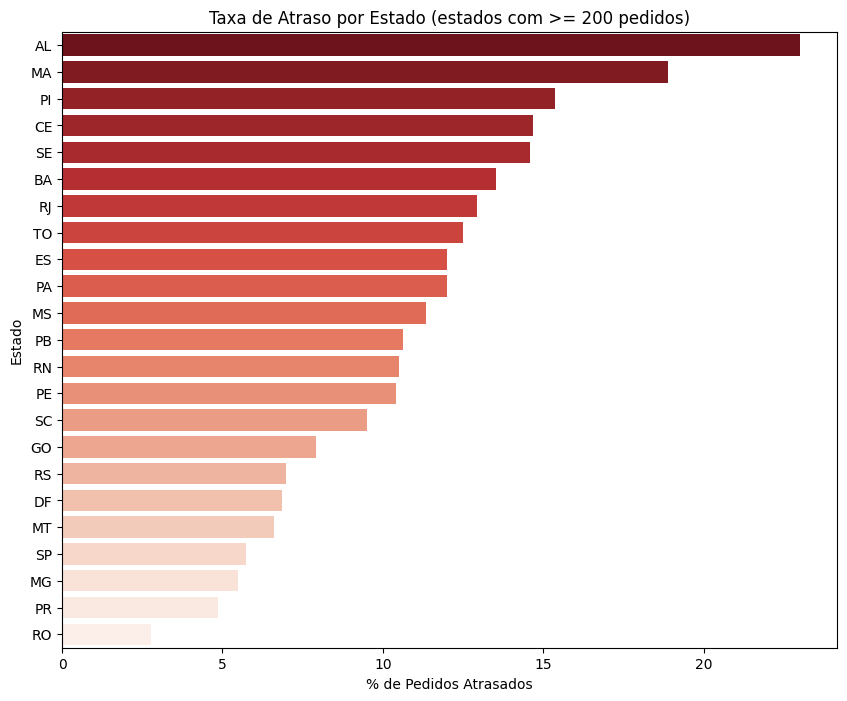

In [57]:
contagem_estado = df_pedidos_unicos['customer_state'].value_counts()
estados_validos = contagem_estado[contagem_estado >= 200].index
df_filtrado = df_pedidos_unicos[df_pedidos_unicos['customer_state'].isin(estados_validos)]

taxa_atraso_estado = (df_filtrado.groupby('customer_state')['atrasou'].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=taxa_atraso_estado.values, y=taxa_atraso_estado.index, hue=taxa_atraso_estado.index,
            palette='Reds_r', legend=False)
plt.xlabel('% de Pedidos Atrasados')
plt.ylabel('Estado')
plt.title('Taxa de Atraso por Estado (estados com >= 200 pedidos)')
plt.show()

***
### Gráfico 3 — Distribuição dos Dias de Atraso/Adiantamento

Histograma que mostra a frequência de pedidos de acordo com o número de dias 
de atraso (valores positivos) ou adiantamento (valores negativos) em relação 
à data estimada de entrega.

**Resultado:** A distribuição é concentrada majoritariamente à esquerda do zero, 
confirmando que a maior parte dos pedidos chega adiantada (entre 5 e 20 dias 
antes do prazo). Uma cauda mais longa à direita revela a existência de outliers — 
pedidos com atrasos extremos (acima de 100 dias) — que, embora raros, merecem 
atenção pontual.


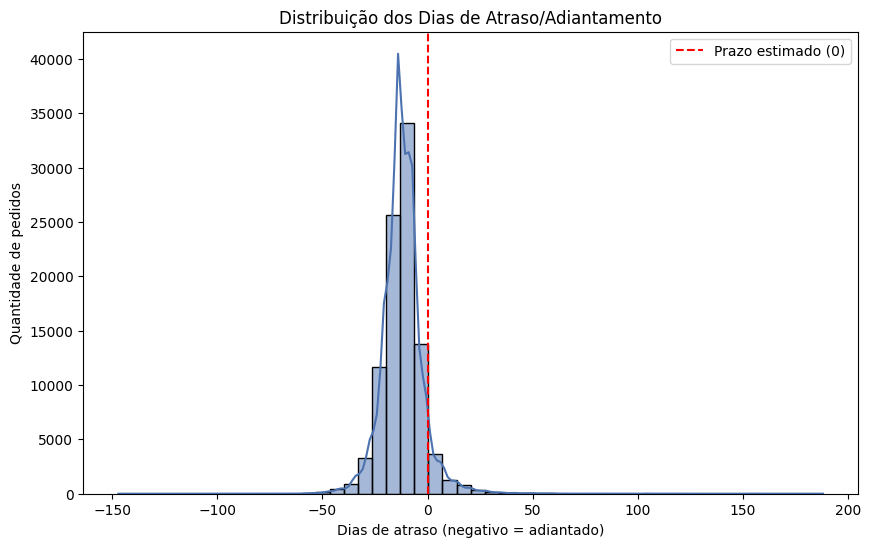

In [52]:
plt.figure(figsize=(10,6))
sns.histplot(df_pedidos_unicos['dias_atraso'].dropna(), bins=50, color='#4C72B0', kde=True)
plt.axvline(0, color='red', linestyle='--', label='Prazo estimado (0)')
plt.xlabel('Dias de atraso (negativo = adiantado)')
plt.ylabel('Quantidade de pedidos')
plt.title('Distribuição dos Dias de Atraso/Adiantamento')
plt.legend()
plt.show()

***
### Gráfico 4 — Evolução da Taxa de Atraso ao Longo do Tempo

Gráfico de linha mostrando como a porcentagem de pedidos atrasados variou 
mês a mês, com base na data de compra.

**Resultado:** A taxa de atraso se manteve relativamente estável e baixa ao 
longo de 2017, mas apresenta um pico expressivo entre novembro de 2017 e 
março de 2018, chegando a mais de 20% em março/2018. Esse período coincide 
com datas de alta demanda (Black Friday e Natal), sugerindo que o volume 
elevado de pedidos pode ter sobrecarregado a capacidade logística.

C:\Users\gusta\AppData\Local\Temp\ipykernel_15576\3572373155.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pedidos_unicos['ano_mes'] = df_pedidos_unicos['order_purchase_timestamp'].dt.to_period('M').astype(str)


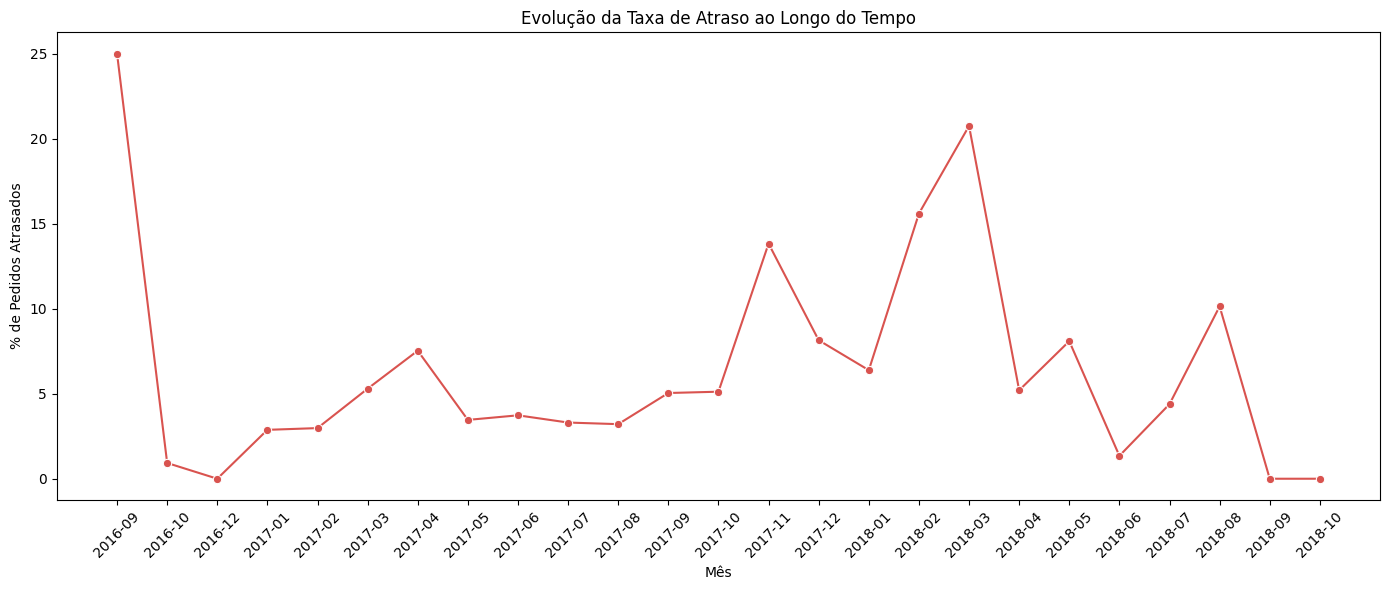

In [53]:
df_pedidos_unicos['ano_mes'] = df_pedidos_unicos['order_purchase_timestamp'].dt.to_period('M').astype(str)
atraso_mensal = df_pedidos_unicos.groupby('ano_mes')['atrasou'].mean() * 100

plt.figure(figsize=(14,6))
sns.lineplot(x=atraso_mensal.index, y=atraso_mensal.values, marker='o', color='#D9534F')
plt.xticks(rotation=45)
plt.xlabel('Mês')
plt.ylabel('% de Pedidos Atrasados')
plt.title('Evolução da Taxa de Atraso ao Longo do Tempo')
plt.tight_layout()
plt.show()

***
### Gráfico 5 — Ticket Médio por Estado

Gráfico de barras com o valor médio gasto por pedido em cada estado 
(considerando apenas estados com volume de pedidos representativo).

**Resultado:** Paraíba (PB), Alagoas (AL) e Pará (PA) apresentam os maiores 
tickets médios, enquanto São Paulo (SP) — apesar de concentrar o maior volume 
de pedidos — tem o menor ticket médio entre os estados analisados. Isso sugere 
que estados mais distantes dos grandes centros tendem a ter poucos pedidos, 
porém de maior valor individual.

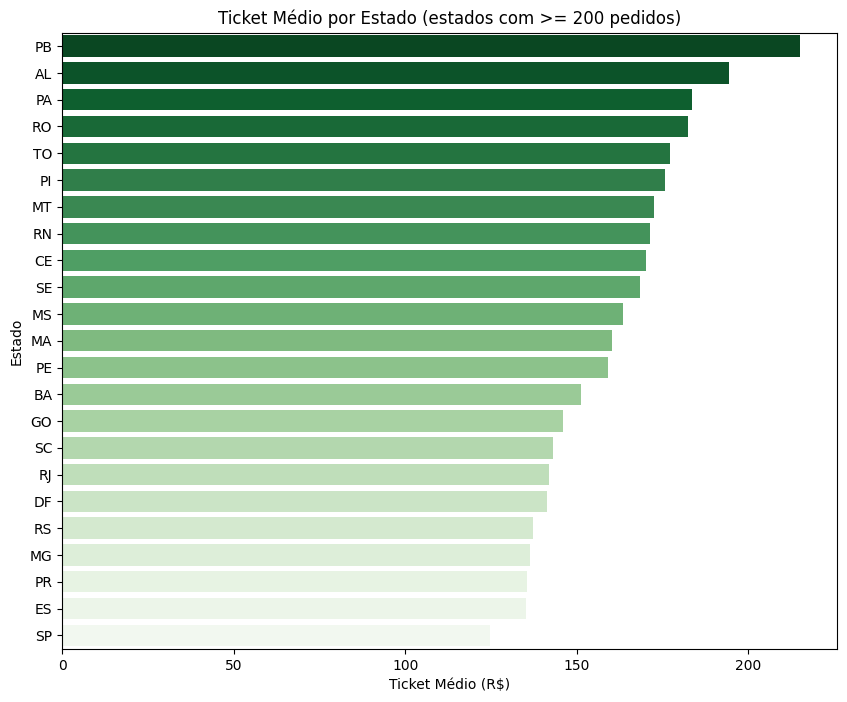

In [54]:
valor_por_pedido = df_final.groupby('order_id')['price'].sum().reset_index()
valor_por_pedido = valor_por_pedido.merge(
    df_pedidos_unicos[['order_id','customer_state']], on='order_id'
)
valor_por_pedido_filtrado = valor_por_pedido[valor_por_pedido['customer_state'].isin(estados_validos)]
ticket_medio = valor_por_pedido_filtrado.groupby('customer_state')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=ticket_medio.values, y=ticket_medio.index, hue=ticket_medio.index,
            palette='Greens_r', legend=False)
plt.xlabel('Ticket Médio (R$)')
plt.ylabel('Estado')
plt.title('Ticket Médio por Estado (estados com >= 200 pedidos)')
plt.show()

***
## Gráfico 6 - Matriz de Correlação entre Variáveis Numéricas

### Descrição

Este mapa de calor apresenta a correlação entre as principais variáveis numéricas do conjunto de dados. A correlação mede a intensidade e a direção da relação linear entre duas variáveis, assumindo valores entre **-1** e **1**.

- Valores próximos de **1** indicam uma forte correlação positiva.
- Valores próximos de **-1** indicam uma forte correlação negativa.
- Valores próximos de **0** indicam pouca ou nenhuma correlação linear.

A análise permite identificar possíveis relações entre variáveis como **preço do pedido**, **valor do frete**, **tempo de entrega** e **dias de atraso**, auxiliando na compreensão dos fatores que podem influenciar o desempenho logístico e o comportamento dos pedidos.

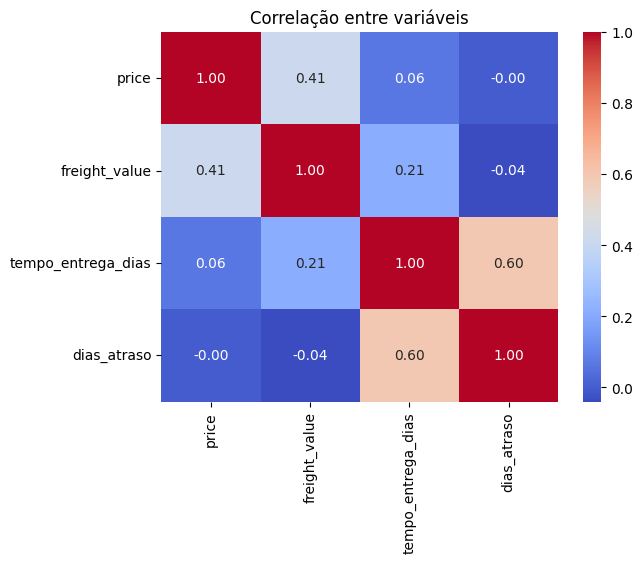

In [61]:
sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlação entre variáveis")
plt.show()

## Conclusões da Análise Exploratória

### Principais achados

**1. Desempenho geral de entrega é bom, mas não uniforme**
No geral, 92,1% dos pedidos são entregues dentro do prazo estimado, e a maioria 
chega com folga (em média, adiantada). Porém, essa boa média nacional esconde 
diferenças regionais importantes.

**2. Desigualdade regional na taxa de atraso**
Estados do Nordeste — especialmente Alagoas (23%), Maranhão (19%) e Piauí (15%) — 
apresentam taxas de atraso significativamente acima da média nacional (7,9%). 
Já estados do Sul e Sudeste, como Rondônia, São Paulo e Paraná, têm os melhores 
índices (abaixo de 5%). Isso indica que a malha logística da Olist é menos 
eficiente para regiões mais distantes dos grandes centros de distribuição.

**3. Ticket médio não segue o mesmo padrão do volume**
Curiosamente, os estados com maior ticket médio (Paraíba, Alagoas, Pará) não 
são os mesmos com maior volume de pedidos. São Paulo, apesar de concentrar a 
maior parte da base de clientes, tem o menor ticket médio — sugerindo um perfil 
de compra mais recorrente e de menor valor, enquanto estados mais distantes 
compram com menos frequência, porém em valores mais altos.

**4. Sazonalidade afeta a taxa de atraso**
A Black Friday de novembro/2017 provocou um pico claro de pedidos (mais de 5x 
o volume normal em um único dia) e, consequentemente, elevou a taxa de atraso 
do mês para 13,8%. Já o período de fevereiro-março/2018 apresentou as piores 
taxas de atraso da série (até 20,7%) sem um aumento proporcional de volume, 
sugerindo um problema operacional pontual não capturado pelos dados 
disponíveis nesse dataset.

**5. Outliers extremos são raros e não distorcem a análise**
Cerca de 38 pedidos (menos de 0,04% da base) apresentaram atrasos superiores 
a 100 dias. Todos possuem status "delivered" e sequência de datas coerente, 
indicando que são casos reais e não erros de dado — porém isolados, sem 
concentração geográfica relevante.

### Limitações da análise

- Os dados cobrem o período de setembro/2016 a agosto/2018, não representando 
  o desempenho atual da operação.
- Não há informação disponível sobre causas específicas de atraso (clima, 
  greves, problemas com transportadoras), o que limita a explicação de picos 
  pontuais como o de fevereiro-março/2018.
- Estados com poucos pedidos (< 200) foram excluídos das comparações por 
  estado, para evitar conclusões estatisticamente não confiáveis.

### Próximos passos sugeridos

- Cruzar os dados de atraso com as avaliações dos clientes (`reviews`) para 
  confirmar se atrasos impactam diretamente a satisfação.
- Trazer a categoria dos produtos (`products`) para verificar se determinados 
  tipos de produto têm maior propensão a atraso.
- Investigar externamente o que ocorreu entre fevereiro e março de 2018 
  (ex: notícias sobre greves ou problemas logísticos no período).